### Loading Processed Data

In [32]:
import pandas as pd
import numpy as np

X_train = pd.read_csv("X_train_prepared.csv", index_col=0)
y_train = pd.read_csv("y_train_prepared.csv", index_col=0).squeeze()

X_test  = pd.read_csv("X_test_processed.csv", index_col=0)
y_test  = pd.read_csv("y_test.csv", index_col=0).squeeze()

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (747, 18)
X_test : (195, 18)


### Baseline KNN with k=5

In [33]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

print("=== Baseline KNN (k=5) ===")
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE : {root_mean_squared_error(y_test, y_pred):.2f}")
print(f"R²   : {r2_score(y_test, y_pred):.4f}")

=== Baseline KNN (k=5) ===
MAE  : 94.65
RMSE : 121.77
R²   : 0.8223


### Fiding the best k for the prediction

In [34]:
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

k_range = range(1, 31)
rmse_scores = []

for k in k_range:
    model = KNeighborsRegressor(n_neighbors=k)
    scores = cross_val_score(
        model, X_train, y_train,
        cv=5,
        scoring="neg_root_mean_squared_error"
    )
    rmse_scores.append(-scores.mean())

best_k = list(k_range)[np.argmin(rmse_scores)]
print(f"Best k: {best_k}  (CV-RMSE = {min(rmse_scores):.2f})")

Best k: 10  (CV-RMSE = 112.33)


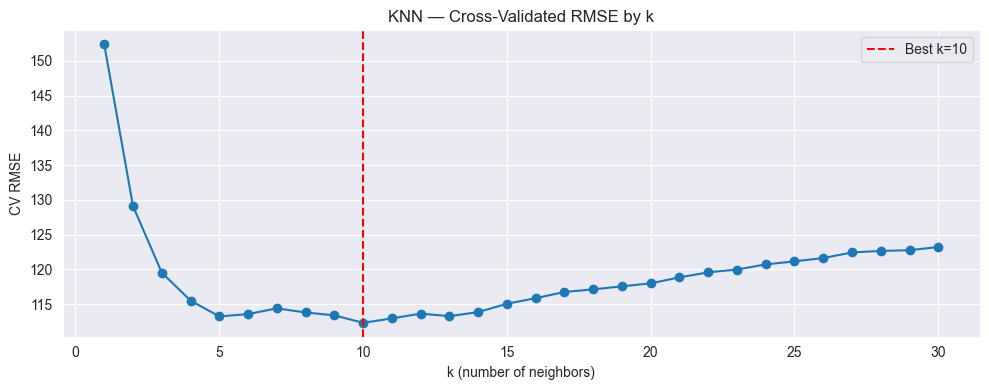

In [35]:
plt.figure(figsize=(10, 4))
plt.plot(list(k_range), rmse_scores, marker="o", linewidth=1.5)
plt.axvline(best_k, color="red", linestyle="--", label=f"Best k={best_k}")
plt.xlabel("k (number of neighbors)")
plt.ylabel("CV RMSE")
plt.title("KNN — Cross-Validated RMSE by k")
plt.legend()
plt.tight_layout()
plt.show()

### Applying KNN after finding the best k (k=10)

In [36]:
knn_best = KNeighborsRegressor(n_neighbors=best_k)
knn_best.fit(X_train, y_train)
y_pred_best = knn_best.predict(X_test)

print(f"=== Best KNN (k={best_k}) ===")
print(f"MAE  : {mean_absolute_error(y_test, y_pred_best):.2f}")
print(f"RMSE : {root_mean_squared_error(y_test, y_pred_best):.2f}")
print(f"R²   : {r2_score(y_test, y_pred_best):.4f}")

=== Best KNN (k=10) ===
MAE  : 95.76
RMSE : 119.74
R²   : 0.8281


### Plotting the result for visualisation

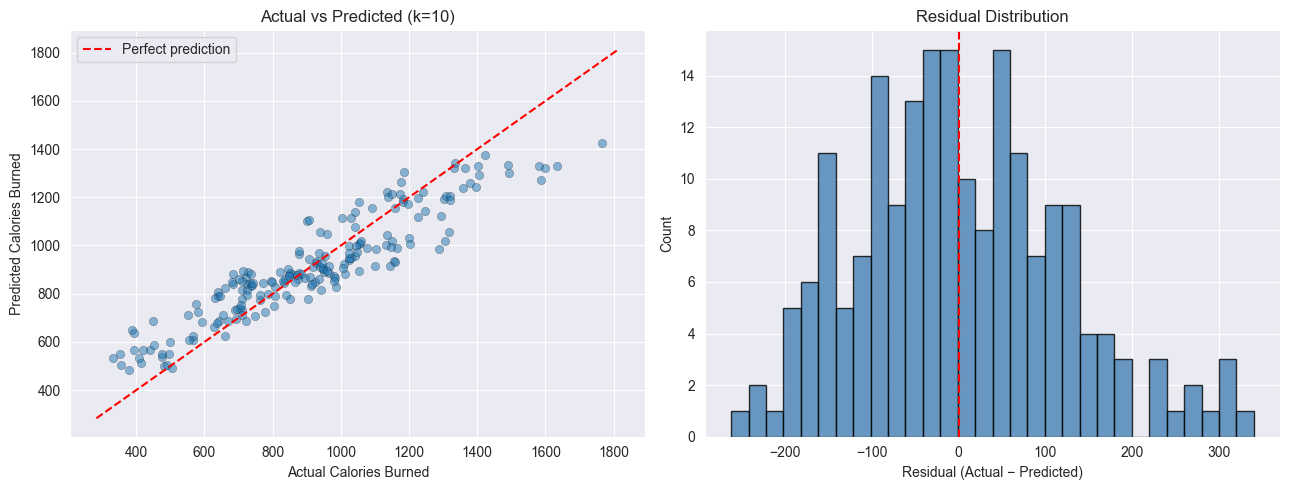

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(y_test, y_pred_best, alpha=0.5, edgecolors="k", linewidths=0.3)
lims = [min(y_test.min(), y_pred_best.min()) - 50,
        max(y_test.max(), y_pred_best.max()) + 50]
ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
ax.set_xlabel("Actual Calories Burned")
ax.set_ylabel("Predicted Calories Burned")
ax.set_title(f"Actual vs Predicted (k={best_k})")
ax.legend()
residuals = y_test.values - y_pred_best
axes[1].hist(residuals, bins=30, edgecolor="k", color="steelblue", alpha=0.8)
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_xlabel("Residual (Actual − Predicted)")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()